In [1]:
import os
import copy

import numpy as np
import yt
from yt.frontends.ramses.field_handlers import RTFieldFileHandler
import matplotlib.pyplot as plt
import scipy

from merlin_spectra.emission import EmissionLineInterpolator
from merlin_spectra import galaxy_visualization

import silmaril

In [2]:
#PATH TO SIMULATION
filename = "C:/Users/jonat/source/repos/UMD/GEMS/ricotti/output_00273/info_00273.txt"

#PATH TO Merlin
merlin_path = "C:/Users/jonat/source/repos/UMD/GEMS/Merlin/"

#PATH TO silmaril/data
data = "C:/Users/jonat/source/repos/UMD/GEMS/Merlin/drivers/data/"


lines=["H1_6562.80A","O1_1304.86A","O1_6300.30A","O2_3728.80A","O2_3726.10A",
       "O3_1660.81A","O3_1666.15A","O3_4363.21A","O3_4958.91A","O3_5006.84A", 
       "He2_1640.41A","C2_1335.66A","C3_1906.68A","C3_1908.73A","C4_1549.00A",
       "Mg2_2795.53A","Mg2_2802.71A","Ne3_3868.76A","Ne3_3967.47A",
       "N5_1238.82A",
       "N5_1242.80A","N4_1486.50A","N3_1749.67A","S2_6716.44A","S2_6730.82A"]

wavelengths=[6562.80, 1304.86, 6300.30, 3728.80, 3726.10, 1660.81, 1666.15,
             4363.21, 4958.91, 5006.84, 1640.41, 1335.66,
             1906.68, 1908.73, 1549.00, 2795.53, 2802.71, 3868.76,
             3967.47, 1238.82, 1242.80, 1486.50, 1749.67, 6716.44, 6730.82]

cell_fields = [
    "Density",
    "x-velocity",
    "y-velocity",
    "z-velocity",
    "Pressure",
    "Metallicity",
    "xHI",
    "xHII",
    "xHeII",
    "xHeIII",
]

epf = [
    ("particle_family", "b"),
    ("particle_tag", "b"),
    ("particle_birth_epoch", "d"),
    ("particle_metallicity", "d"),
]

In [3]:
# Ionization Parameter Field
# Based on photon densities in bins 2-4
# Don't include bin 1 -> Lyman Werner non-ionizing
def _ion_param(field, data):
    p = RTFieldFileHandler.get_rt_parameters(ds).copy()
    p.update(ds.parameters)

    cgs_c = 2.99792458e10     #light velocity

    # Convert to physical photon number density in cm^-3
    pd_2 = data['ramses-rt','Photon_density_2']*p["unit_pf"]/cgs_c
    pd_3 = data['ramses-rt','Photon_density_3']*p["unit_pf"]/cgs_c
    pd_4 = data['ramses-rt','Photon_density_4']*p["unit_pf"]/cgs_c

    photon = pd_2 + pd_3 + pd_4

    return photon/data['gas', 'number_density']


def _my_temperature(field, data):
    #y(i): abundance per hydrogen atom
    XH_RAMSES=0.76 #defined by RAMSES in cooling_module.f90
    YHE_RAMSES=0.24 #defined by RAMSES in cooling_module.f90
    mH_RAMSES=yt.YTArray(1.6600000e-24,"g") #defined by RAMSES in cooling_module.f90
    kB_RAMSES=yt.YTArray(1.3806200e-16,"erg/K") #defined by RAMSES in cooling_module.f90

    dn=data["ramses","Density"].in_cgs()
    pr=data["ramses","Pressure"].in_cgs()
    yHI=data["ramses","xHI"]
    yHII=data["ramses","xHII"]
    yHe = YHE_RAMSES*0.25/XH_RAMSES
    yHeII=data["ramses","xHeII"]*yHe
    yHeIII=data["ramses","xHeIII"]*yHe
    yH2=1.-yHI-yHII
    yel=yHII+yHeII+2*yHeIII
    mu=(yHI+yHII+2.*yH2 + 4.*yHe) / (yHI+yHII+yH2 + yHe + yel)
    return pr/dn * mu * mH_RAMSES / kB_RAMSES


#number density of hydrogen atoms
def _my_H_nuclei_density(field, data):
    dn=data["ramses","Density"].in_cgs()
    XH_RAMSES=0.76 #defined by RAMSES in cooling_module.f90
    YHE_RAMSES=0.24 #defined by RAMSES in cooling_module.f90
    mH_RAMSES=yt.YTArray(1.6600000e-24,"g") #defined by RAMSES in cooling_module.f90

    return dn*XH_RAMSES/mH_RAMSES


def _OII_ratio(field, data):
    # TODO lum or flux?
    #return data['gas', 'flux_O2_3728.80A']/data['gas', 'flux_O2_3726.10A']
    flux1 = data['gas', 'flux_O2_3728.80A']
    flux2 = data['gas', 'flux_O2_3726.10A']

    flux2 = np.where(flux2 < 1e-30, 1e-30, flux2)

    ratio = flux1 / flux2

    return ratio


def _pressure(field, data):
    if 'hydro_thermal_pressure' in dir(ds.fields.ramses): # and 
        #'Pressure' not in dir(ds.fields.ramses):
        return data['ramses', 'hydro_thermal_pressure']


def _xHI(field, data):
    if 'hydro_xHI' in dir(ds.fields.ramses): # and \
        #'xHI' not in dir(ds.fields.ramses):
        return data['ramses', 'hydro_xHI']


def _xHII(field, data):
    if 'hydro_xHII' in dir(ds.fields.ramses): # and \
        #'xHII' not in dir(ds.fields.ramses):
        return data['ramses', 'hydro_xHII']


def _xHeII(field, data):
    if 'hydro_xHeII' in dir(ds.fields.ramses): # and \
        #'xHeII' not in dir(ds.fields.ramses):
        return data['ramses', 'hydro_xHeII']


def _xHeIII(field, data):
    if 'hydro_xHeIII' in dir(ds.fields.ramses): # and \
        #'xHeIII' not in dir(ds.fields.ramses):
        return data['ramses', 'hydro_xHeIII']

In [4]:
def get_luminosity(self, line):
    '''
    Return function for derived luminosity field of each line.
    The Cloudy flux is obtained assuming a gas cloud of height = 1 cm,
    Returns flux values erg s^-1 c^-2.
    Multiply the flux at each cell by the volume of the cell
    to obtain the intrinsic luminosity.

    line (str): desired emission line from field
    '''

    def _luminosity(field, data):
        return data['gas', 'flux_' + line]*data['gas', 'volume']
    return copy.deepcopy(_luminosity)


In [5]:
ds = yt.load(filename, extra_particle_fields=epf)

yt : [INFO     ] 2026-03-02 17:04:54,577 Parameters: current_time              = 0.3604448649237178 Gyr
yt : [INFO     ] 2026-03-02 17:04:54,578 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2026-03-02 17:04:54,579 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-02 17:04:54,579 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2026-03-02 17:04:54,580 Parameters: cosmological_simulation   = True
yt : [INFO     ] 2026-03-02 17:04:54,580 Parameters: current_redshift          = 12.171087046255657
yt : [INFO     ] 2026-03-02 17:04:54,581 Parameters: omega_lambda              = 0.685000002384186
yt : [INFO     ] 2026-03-02 17:04:54,581 Parameters: omega_matter              = 0.314999997615814
yt : [INFO     ] 2026-03-02 17:04:54,581 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2026-03-02 17:04:54,582 Parameters: hubble_constant           = 0.674000015258789


In [6]:

'''
-------------------------------------------------------------------------------
Load Simulation Data
Add Derived Fields
-------------------------------------------------------------------------------
'''


ds.add_field(
    ("gas","number_density"),
    function=_my_H_nuclei_density,
    sampling_type="cell",
    units="1/cm**3",
    force_override=True
)

ds.add_field(
    ("ramses","Pressure"),
    function=_pressure,
    sampling_type="cell",
    units="1",
    #force_override=True
)

ds.add_field(
    ("ramses","xHI"),
    function=_xHI,
    sampling_type="cell",
    units="1",
    #force_override=True
)

ds.add_field(
    ("ramses","xHII"),
    function=_xHII,
    sampling_type="cell",
    units="1",
    #force_override=True
)

ds.add_field(
    ("ramses","xHeII"),
    function=_xHeII,
    sampling_type="cell",
    units="1",
    #force_override=True
)

ds.add_field(
    ("ramses","xHeIII"),
    function=_xHeIII,
    sampling_type="cell",
    units="1",
    #force_override=True
)

ds.add_field(
    ("gas","my_temperature"),
    function=_my_temperature,
    sampling_type="cell",
    # TODO units
    #units="K",
    #units="K*cm**3/erg",
    units='K*cm*dyn/erg',
    force_override=True
)

# Ionization parameter
ds.add_field(
    ('gas', 'ion_param'),
    function=_ion_param,
    sampling_type="cell",
    units="cm**3",
    force_override=True
)

ds.add_field(
    ("gas","my_H_nuclei_density"),
    function=_my_H_nuclei_density,
    sampling_type="cell",
    units="1/cm**3",
    force_override=True
)


# Normalize by Density Squared Flag
dens_normalized = False
if dens_normalized: 
    flux_units = '1/cm**6'
    lum_units = '1/cm**3'
else:
    flux_units = '1'
    lum_units = 'cm**3'

# Instance of EmissionLineInterpolator for line list at filename
#line_list = os.path.join(os.getcwd(), 'data/linelist.dat')
# TODO alter for zaratan
line_list = os.path.join(merlin_path + 'src/merlin_spectra/linelists/linelist2.dat')
emission_interpolator = EmissionLineInterpolator(line_list, lines)

# Add flux and luminosity fields for all lines in the list
for i, line in enumerate(lines):
    ds.add_field(
        ('gas', 'flux_' + line),
        function=emission_interpolator.get_line_emission(
            i, dens_normalized=dens_normalized
        ),
        sampling_type='cell',
        units=flux_units,
        force_override=True,
    )

    ds.add_field(
        ('gas', 'luminosity_' + line),
        function=emission_interpolator.get_luminosity(lines[i]),
        sampling_type='cell',
        units=lum_units,
        force_override=True,
    )


ds.add_field(
    ("gas","OII_ratio"),
    function=_OII_ratio,
    sampling_type="cell",
    units="1",
    force_override=True
)
# TODO


ad = ds.all_data()
print(ds.field_list)
print(ds.derived_field_list)

yt : [WARNING  ] 2026-03-02 17:04:54,825 This output has no cooling fields
yt : [INFO     ] 2026-03-02 17:04:55,232 Adding particle_type: DM
yt : [INFO     ] 2026-03-02 17:04:55,239 Adding particle_type: star
yt : [INFO     ] 2026-03-02 17:04:55,247 Adding particle_type: cloud
yt : [INFO     ] 2026-03-02 17:04:55,254 Adding particle_type: dust
yt : [INFO     ] 2026-03-02 17:04:55,261 Adding particle_type: star_tracer
yt : [INFO     ] 2026-03-02 17:04:55,269 Adding particle_type: cloud_tracer
yt : [INFO     ] 2026-03-02 17:04:55,277 Adding particle_type: dust_tracer
yt : [INFO     ] 2026-03-02 17:04:55,285 Adding particle_type: gas_tracer
yt : [WARNING  ] 2026-03-02 17:04:55,294 Field ('ramses', 'Pressure') already exists. To override use `force_override=True`.


minU=-9.0, maxU=2.0, stepU=0.5, minN=-4.0, maxN=7.0, stepN=0.5, minT=1.0, maxT=8.0, stepT=0.2
Line List Shape = (25, 19044)
23 23 36
[('gravity', 'Potential'), ('gravity', 'x-acceleration'), ('gravity', 'y-acceleration'), ('gravity', 'z-acceleration'), ('io', 'particle_birth_epoch'), ('io', 'particle_family'), ('io', 'particle_identity'), ('io', 'particle_mass'), ('io', 'particle_metallicity'), ('io', 'particle_position_x'), ('io', 'particle_position_y'), ('io', 'particle_position_z'), ('io', 'particle_refinement_level'), ('io', 'particle_tag'), ('io', 'particle_velocity_x'), ('io', 'particle_velocity_y'), ('io', 'particle_velocity_z'), ('nbody', 'particle_mass'), ('nbody', 'particle_position_x'), ('nbody', 'particle_position_y'), ('nbody', 'particle_position_z'), ('nbody', 'particle_velocity_x'), ('nbody', 'particle_velocity_y'), ('nbody', 'particle_velocity_z'), ('ramses', 'Density'), ('ramses', 'Metallicity'), ('ramses', 'Pressure'), ('ramses', 'hydro_refinement-param'), ('ramses', 

In [7]:
def get_filter_interpolator(
    table_file: str,
    filter_file: str,
    z: float = 0.0,
):
    """
    Returns a CubicSpline interpolator for a given JWST filter
    based on the starburst spectrum table.

    Parameters
    ----------
    table_file : str
        Absolute or relative path to starburst spectrum table
    filter_file : str
        Absolute or relative path to filter throughput file
    z : float
        Redshift of the galaxy (default 0)

    Returns
    -------
    interpolator : scipy.interpolate.CubicSpline
        Function of stellar age [Myr] giving mean photon-rate-weighted flux
        through the filter.
    """
    # Load filter throughput
    filter_data = np.loadtxt(filter_file, skiprows=1)
    wav_angs = filter_data[:, 0] * 1e4  # microns -> angstroms, rest-frame
    
    # Return CubicSpline interpolator
    return wav_angs, scipy.interpolate.CubicSpline(wav_angs, filter_data[:, 1])


In [8]:
table_file = data + r"fig7e.dat"

filters = ['F070W', 'F090W', 'F115W', 'F140M', 'F150W', 
           'F150W', 'F162M', 'F164N', 'F182M', 'F187N', 
           'F200W', 'F210M', 'F212N', 'F250M', 'F277W', 
           'F300M', 'F322W2', 'F323N', 'F335M', 'F356W', 
           'F360M', 'F405N', 'F410M', 'F430M', 'F444W', 
           'F460M', 'F466N', 'F470N', 'F480M', 'WLP4']


filter = filters[14]

In [9]:
def get_filter_luminosity(filter):
    filter_file = data + r"mean_throughputs/" + filter + r"_mean_system_throughput.txt"
    z=ds.current_redshift
    angs, interp = get_filter_interpolator(table_file, filter_file, z=z)

    def _filter_lum(field, data):
        """
        Sum of line luminosities weighted by the filter interpolator
        """
        lum_sum = np.zeros_like(data['gas', 'luminosity_' + lines[0]])
        for line, wav in zip(lines, wavelengths):
            shifted_wav = wav * (1+z)
            weight = interp(shifted_wav)  # filter weight for this line
            weight = np.where(shifted_wav >= angs[0] and shifted_wav <= angs[-1], weight, 0)
            if weight >= 1e-6:
                lum_sum += data['gas', 'luminosity_' + line] * weight
        return lum_sum

    return copy.deepcopy(_filter_lum)

In [10]:
x1 = ad["star", "particle_position_x"].in_units("pc")
y1 = ad["star", "particle_position_y"].in_units("pc")
z1 = ad["star", "particle_position_z"].in_units("pc")

center_pc = (np.mean(x1), np.mean(y1), np.mean(z1))

viz = galaxy_visualization.VisualizationManager(filename, lines, wavelengths)
star_ctr = viz.star_center(ad)
sp = ds.sphere(star_ctr, (3000, "pc"))
sp_lum = ds.sphere(star_ctr, (10, 'kpc'))
width = (1500, 'pc')

yt : [INFO     ] 2026-03-02 17:04:55,637 Identified   384/  384 intersecting domains (  385 through hilbert key indexing)


Filename = C:/Users/jonat/source/repos/UMD/GEMS/ricotti/output_00273/info_00273.txt
File Directory = C:/Users/jonat/source/repos/UMD/GEMS/ricotti/output_00273
Output File = output_00273
Simulation Run = 00273
Analysis Directory = analysis/output_00273_analysis


In [11]:
for f in filters:
    ds.add_field(
        ("gas", "lum_filter_" + f),  # field name
        function=get_filter_luminosity(f),
        units=lum_units,          # adjust if your line luminosities have different units
        sampling_type="cell",
        force_override=True
    )

In [24]:
def _flux_total(field, data):
    """
    Sum of line luminosities weighted by the filter interpolator
    """
    flux_sum = np.zeros_like(data['gas', 'flux_' + lines[0]])
    for line, wav in zip(lines, wavelengths):
        flux_sum += data['gas', 'flux_' + line]
    return flux_sum

In [25]:
ds.add_field(
        ("gas", "flux_total"),  # field name
        function=_flux_total,
        units=flux_units,          # adjust if your line luminosities have different units
        sampling_type="cell",
        force_override=True
    )

In [26]:
def create_phase_plot(ad, x_field = "density", y_field = "temperature", z_field = "flux_total", x_bins = None, y_bins = None, weight_field = None):
    """"
    Create a phase plot showing distribution of flux across two variables.

    Parameters:
    ----------
    ad: yt all_data container
    x_field (str): field for x-axis
    y_field (str): field for y-axis
    z_field (str): flux field to be binned
    x_bins (tuple): (min, max) for x-axis
    y_bins (tuple): (min, max) for y-axis
    weight_field (str): field to weight the distribution

    Outputs:
    -------
    None: displays the yt phase plot
    """

    plot = yt.PhasePlot(ad, x_field, y_field, [z_field], weight_field = weight_field)
    
    if x_bins:
        plot.set_xlim(x_bins[0], x_bins[1])
    if y_bins:
        plot.set_ylim(y_bins[0], y_bins[1])
        
    plot.set_title(z_field, f"phase plot: {z_field} distribution")
    plot.set_cmap(z_field, "viridis")
    plot.show()

    return None


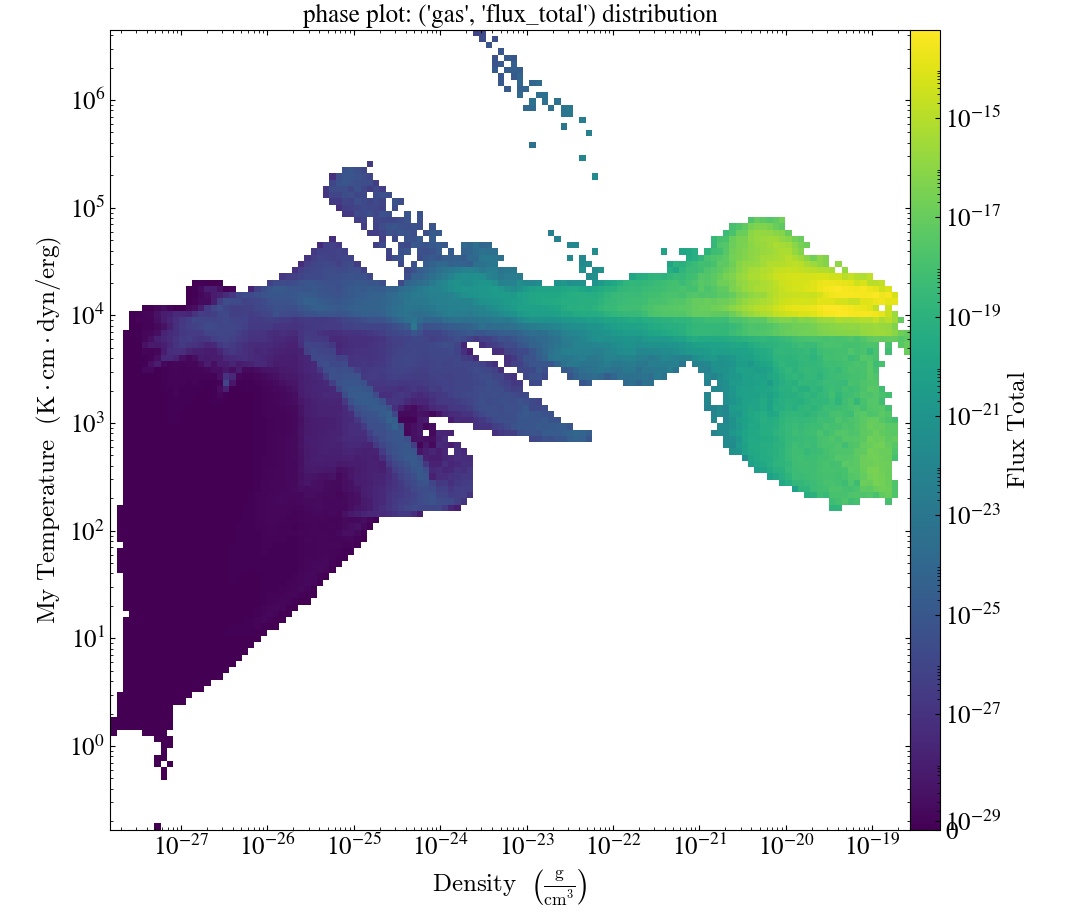

In [29]:
# visualize phase plot
create_phase_plot(
    ad = ds, 
    x_field = ("gas", "density"), 
    y_field = ("gas", "my_temperature"), 
    z_field = ("gas", "flux_total"),
    # x_bins = (1e-31, 1e-23),         
    # y_bins = (1e3, 1e7),             
    weight_field = None
)

In [32]:

# function use to calculate resolution of the filter
def calculate_original_resolution(wavelength):         
    wavelength_array = np.array(wavelength)
    N = len(wavelength_array)
    delta_wl = np.abs((wavelength_array[-1] - wavelength_array[0])) / (N - 1) 
    wl_mid = np.median(wavelength_array) 
    R_orig = wl_mid / delta_wl 
    return R_orig

# function use to change from flux to surface brightness
def flux_to_surface_brightness(I, z):
    I_0 = 1 / 9
    I_result = 1.56e-6 * (I / I_0) * ((1 + z) / 10)**(-4)
    return I_result

# function use to change from flux to magnitude
def flux_to_magnitude(I_nu, z):
    mag_result = -2.5 * np.log10(I_nu) + 8.9
    return mag_result

# function use to calculate width of your filter
def calculate_filter_width(filter_path):
    if not os.path.exists(filter_path):
        print(f"  warning: filter file {filter_path} not found")
        return None
        
    filter_data = np.loadtxt(filter_path, skiprows = 1)
    wavelengths = filter_data[:, 0]
    transmission = filter_data[:, 1]
        
    mask = transmission > 0
    if np.sum(mask) == 0:
        print(f"  warning: no transmission > 0 in filter {filter_path}")
        return None
        
    wl_min = wavelengths[mask].min()
    wl_max = wavelengths[mask].max()
    delta_wl_micron = wl_max - wl_min
    delta_wl_angstrom = delta_wl_micron * 1e4
        
    return delta_wl_angstrom

In [33]:
def create_projection_plot(ds, field_name, ctr_at_code, plt_wdth = 400, plot_units = None, z = None, distance_pc = None, axis_units = "arcsec", filter_path = None):
    """"
    Create a projection plot of a specific flux field.

    Parameters:
    ----------
    ds: yt dataset object
    field_name (str): name of the field to project
    ctr_at_code (np.ndarray): center of the plot in code units
    plt_wdth (float): width of the plot in parsecs
    plot_units (str): "flux", "jy_arcsec", or "magnitude"
    z (float): redshift for unit conversion
    distance_pc (float): distance to object for angular size calculation
    axis_units (str): "arcsec" or "pc"
    filter_path (str): path to filter file for accurate delta_wl calculation

    Outputs:
    -------
    None: displays the matplotlib figure
    """

    # create projection to get data
    proj = yt.ProjectionPlot(ds, "z", ("gas", field_name), width = (plt_wdth, "pc"), center = ctr_at_code)
    p_frb = proj.frb
    flux_data = np.array(p_frb["gas", field_name])

    # handle filter width
    delta_wl = 1.988e4 
    if filter_path:
        delta_wl = calculate_filter_width(filter_path)

    # unit conversion logic
    if plot_units == None:
        plot_data = np.log10(flux_data)
        colorbar_label = "log10(flux [erg s$^{-1}$ cm$^{-2}$])"
        cmap = "viridis"
    elif plot_units == "jy_arcsec2":
        flux_per_A = flux_data / delta_wl
        sb = flux_to_surface_brightness(flux_per_A, z = z)
        plot_data = np.log10(sb) + 9
        colorbar_label = "log10(nJy arcsec$^{-2}$)"
        cmap = "viridis"
    elif plot_units == "magnitude_arcsec2":
        flux_per_A = flux_data / delta_wl
        sb = flux_to_surface_brightness(flux_per_A, z = z)
        plot_data = flux_to_magnitude(sb, z = z)
        colorbar_label = "magnitude arcsec$^{-2}$"
        cmap = "viridis_r"

    # axis extent
    if axis_units == "arcsec":
        pc_to_cm = 3.086e18
        ang_rad = ((plt_wdth * pc_to_cm) / 2) / (distance_pc * pc_to_cm) * (180/np.pi) * 3600
        extent = [-ang_rad, ang_rad, -ang_rad, ang_rad]
    elif axis_units == "pc":
        extent = [-plt_wdth/2, plt_wdth/2, -plt_wdth/2, plt_wdth/2]

    fig, ax = plt.subplots(figsize = (20, 10))
    im = ax.imshow(plot_data, extent = extent, cmap = cmap, origin = "lower")
    ax.set_xlabel(axis_units)
    ax.set_ylabel(axis_units)
    plot_title = f"projection plot: {field_name} ({plot_units})"
    ax.set_title(plot_title, fontsize = 14, pad = 20)
    plt.colorbar(im, label = colorbar_label)
    plt.show()

    return None

In [34]:

from astropy.cosmology import FlatLambdaCDM

In [ ]:
# define useful inputs
input_path = "output_00273/info_00273.txt"
z = 10 # redshift
filter_file = "F200W_filter.txt"

# calculate distance of object for defined redshift
cosmo = FlatLambdaCDM(H0 = 70, Om0 = 0.3)
distance_Mpc = cosmo.angular_diameter_distance_z1z2(0, z)
distance_pc = distance_Mpc.to("pc").value

array([0.49117112, 0.49277624, 0.49474927])

yt : [INFO     ] 2026-03-02 17:34:43,278 Identified   162/  384 intersecting domains (  385 through hilbert key indexing)
yt : [INFO     ] 2026-03-02 17:37:12,143 Projection completed
yt : [INFO     ] 2026-03-02 17:37:12,145 xlim = 0.491120 0.491223
yt : [INFO     ] 2026-03-02 17:37:12,146 ylim = 0.492725 0.492828
yt : [INFO     ] 2026-03-02 17:37:12,149 xlim = 0.491120 0.491223
yt : [INFO     ] 2026-03-02 17:37:12,150 ylim = 0.492725 0.492828
yt : [INFO     ] 2026-03-02 17:37:12,153 Making a fixed resolution buffer of (('gas', 'flux_total')) 800 by 800


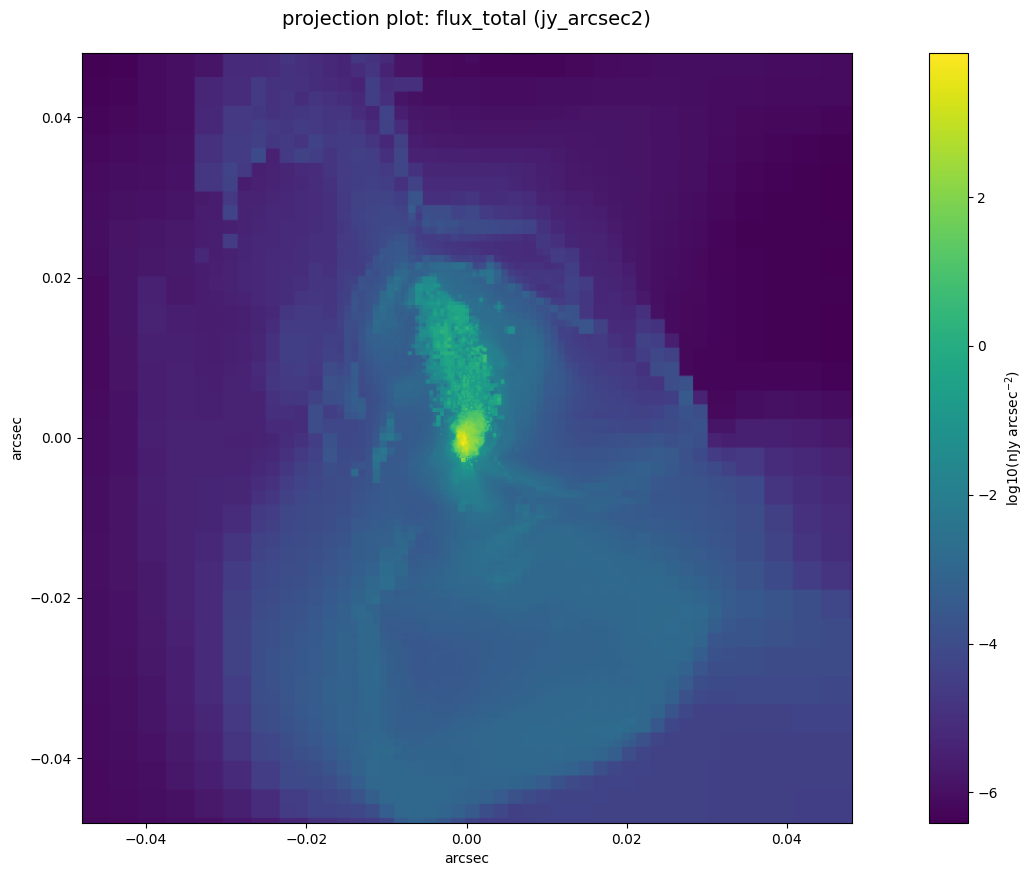

In [43]:
# visualize projection plot
create_projection_plot(
    ds = ds, 
    field_name = "flux_total", # options: "flux_contH", "flux_2p", "flux_ff", "flux_total" 
    ctr_at_code = star_ctr,        
    z = z,                    
    distance_pc = distance_pc,    
    plt_wdth = 400,         
    plot_units = "jy_arcsec2", # options: None, "jy_arcsec2", "magnitude_arcsec2"
    axis_units = "arcsec", # options: "arcsec", "pc"
    filter_path = data + r"mean_throughputs/" + r"F200W" + r"_mean_system_throughput.txt"
)

In [12]:
filter = filters[14]

yt : [INFO     ] 2026-03-02 17:05:03,833 Identified   375/  384 intersecting domains (  375 through hilbert key indexing)
yt : [INFO     ] 2026-03-02 17:05:31,124 Projection completed
yt : [INFO     ] 2026-03-02 17:05:31,140 xlim = 0.490978 0.491364
yt : [INFO     ] 2026-03-02 17:05:31,141 ylim = 0.492583 0.492970
yt : [INFO     ] 2026-03-02 17:05:31,144 xlim = 0.490978 0.491364
yt : [INFO     ] 2026-03-02 17:05:31,144 ylim = 0.492583 0.492970
yt : [INFO     ] 2026-03-02 17:05:31,149 Making a fixed resolution buffer of (('gas', 'lum_filter_F277W')) 800 by 800



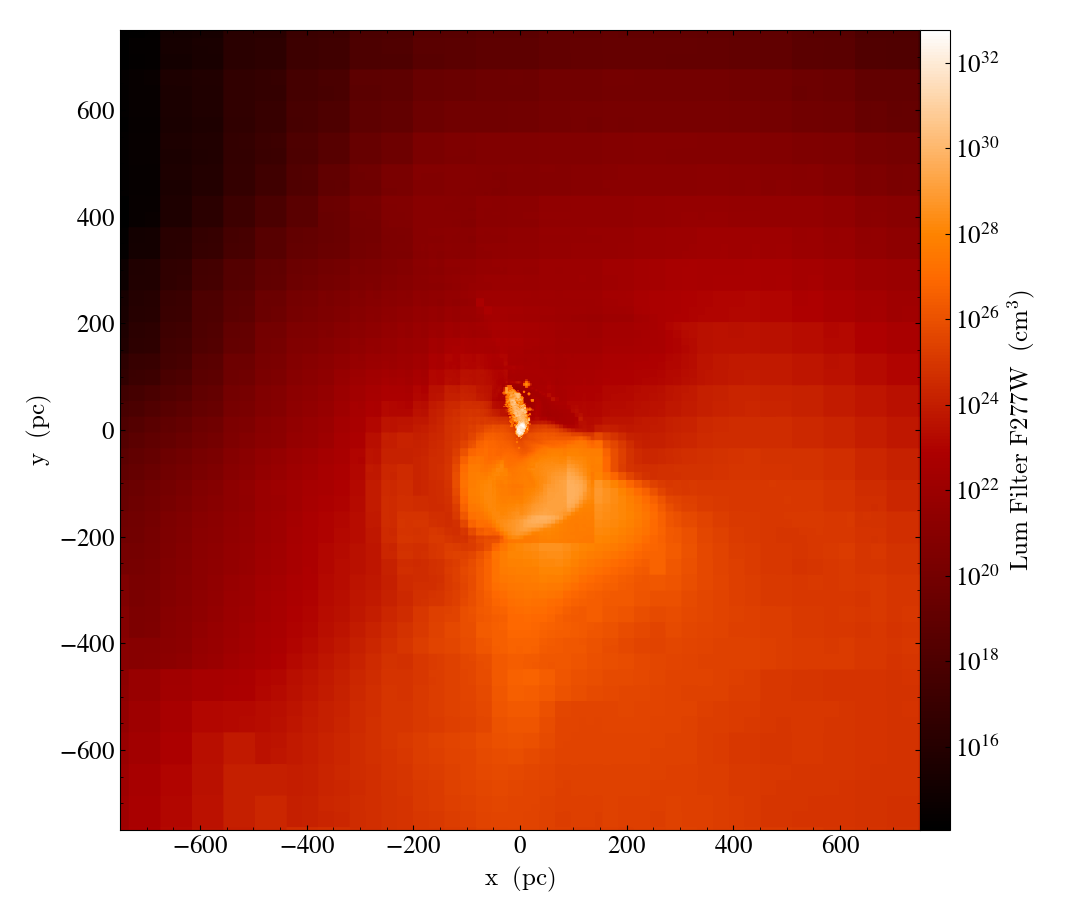

In [13]:
field = ('gas', 'lum_filter_' + filter)
proj = yt.ProjectionPlot(ds, "z", field, width=width, data_source=sp, center=star_ctr, weight_field=('gas', 'my_H_nuclei_density'))
proj.set_cmap(field, "RED TEMPERATURE")
proj.show()

In [14]:

@yt.derived_field(name = ("star", "stellar_ages"), units = "Myr", sampling_type = "particle", force_override = True)
def _age(field, data):
    """
    cgs_yr = 3.1556926e7  # 1yr (in s)
    cgs_pc = 3.08567758e18  # pc (in cm)
    h_0 = data.ds.hubble_constant * 100 # hubble parameter (km/s/Mpc)
    h_0_invsec = h_0 * 1e5 / (1e6 * cgs_pc)  # hubble constant h [km/s Mpc-1]->[1/sec]
    h_0inv_yr = 1 / h_0_invsec / cgs_yr  # 1/h_0 [yr]
    star_age_myr = data["io", "particle_birth_epoch"] * h_0inv_yr / 1e6 + 13.787 * 1e3
    """
    time = data.ds.current_time.in_units("Myr")
    t_birth = [data.ds.quan(i, "code_time").in_units("Myr") for i in data["star", "particle_birth_epoch"]]

    return data.ds.arr(time + t_birth, "Myr")

ds.add_field(("star", "stellar_ages"), function = _age, units = "Myr", sampling_type = "particle", force_override = True)


In [15]:
def get_filter_stellar_luminosity(filter):
    lum = {}
    ages = np.array(ad["star", "stellar_ages"])
    # Build a luminosity lookup table
    unique_ages = np.unique(ages)
    lum = {s: silmaril.galaxy.lum_lookup_filtered(
                s, ds.current_redshift,
                table_file=table_file,
                filter_name=filter)
        for s in unique_ages}

    # Build ret = luminosity per particle
    ret = np.array([lum[a] for a in ages])

    # Store on ds.index so yt can access it
    ds.index.lum_array = ret
    # Chunk-aware luminosity field
    def _lum(field, data):
        idx = data["star", "particle_index"].astype(int)

        out = np.zeros(idx.shape, dtype=float)

        mask = (idx >= 0) & (idx < len(data.ds.index.lum_array))

        out[mask] = data.ds.index.lum_array[idx[mask]]

        return data.ds.arr(out, lum_units)
    
    return copy.deepcopy(_lum)

# Register field
for f in filters:
    ds.add_field(
        ("star", "lum_" + f), 
        function = get_filter_stellar_luminosity(f), 
        units=lum_units,
        sampling_type = "particle", 
        force_override = True
        )


In [16]:
ds.derived_field_list

[('DM', 'mesh_id'),
 ('DM', 'particle_angular_momentum'),
 ('DM', 'particle_angular_momentum_magnitude'),
 ('DM', 'particle_angular_momentum_x'),
 ('DM', 'particle_angular_momentum_y'),
 ('DM', 'particle_angular_momentum_z'),
 ('DM', 'particle_birth_epoch'),
 ('DM', 'particle_family'),
 ('DM', 'particle_identity'),
 ('DM', 'particle_index'),
 ('DM', 'particle_mass'),
 ('DM', 'particle_metallicity'),
 ('DM', 'particle_ones'),
 ('DM', 'particle_position'),
 ('DM', 'particle_position_cylindrical_radius'),
 ('DM', 'particle_position_cylindrical_theta'),
 ('DM', 'particle_position_cylindrical_z'),
 ('DM', 'particle_position_relative_x'),
 ('DM', 'particle_position_relative_y'),
 ('DM', 'particle_position_relative_z'),
 ('DM', 'particle_position_spherical_phi'),
 ('DM', 'particle_position_spherical_radius'),
 ('DM', 'particle_position_spherical_theta'),
 ('DM', 'particle_position_x'),
 ('DM', 'particle_position_y'),
 ('DM', 'particle_position_z'),
 ('DM', 'particle_radial_velocity'),
 ('DM',

In [17]:
for f in filters:
    ds.add_deposited_particle_field(
        ("star", "lum_" + f), method="sum",
    )

yt : [WARNING  ] 2026-03-02 17:06:39,043 Field ('deposit', 'star_sum_lum_F150W') already exists. To override use `force_override=True`.


yt : [INFO     ] 2026-03-02 17:06:39,095 Identified 1 intersecting domains
yt : [INFO     ] 2026-03-02 17:06:41,914 Projection completed
yt : [INFO     ] 2026-03-02 17:06:41,915 xlim = 0.490978 0.491364
yt : [INFO     ] 2026-03-02 17:06:41,916 ylim = 0.492583 0.492970
yt : [INFO     ] 2026-03-02 17:06:41,920 xlim = 0.490978 0.491364
yt : [INFO     ] 2026-03-02 17:06:41,921 ylim = 0.492583 0.492970
yt : [INFO     ] 2026-03-02 17:06:41,922 Making a fixed resolution buffer of (('deposit', 'star_sum_lum_F277W')) 800 by 800



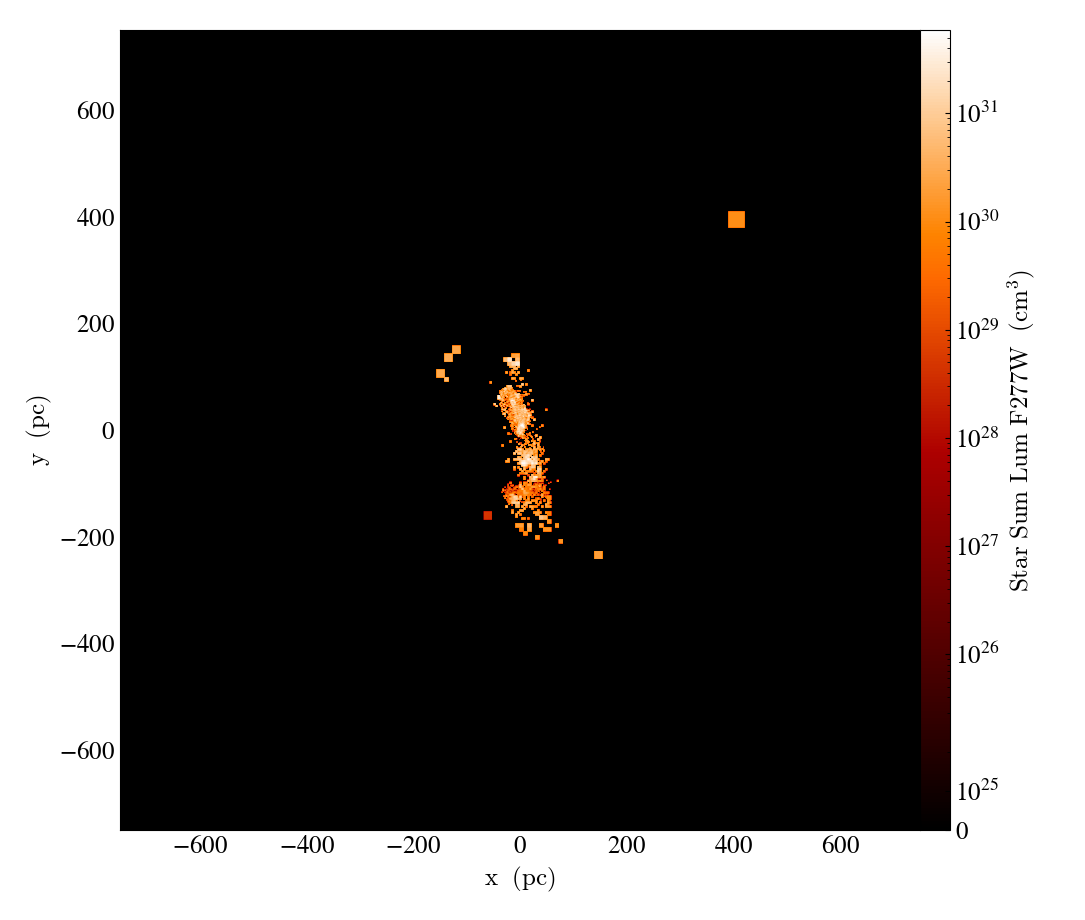

In [18]:
field3 = ('deposit', 'star_sum_lum_' + filter)
proj3 = yt.ProjectionPlot(ds, "z", field3, width=width, data_source=sp, center=center_pc, weight_field=('gas', 'my_H_nuclei_density'))
proj3.set_cmap(field3, "RED TEMPERATURE")
proj3.show()

In [19]:
def total_lum_filtered(filter):
    def _total_lum(field, data):
        return data["gas", "lum_filter_" + filter] + data["deposit", "star_sum_lum_" + filter]
    
    return copy.deepcopy(_total_lum)

for f in filters:
    ds.add_field(
        ("gas", "total_lum_" + f),  # field name
        function=total_lum_filtered(f),
        units=lum_units,          # adjust if your line luminosities have different units
        sampling_type="cell",
        force_override=True
    )

In [20]:
for f in filters:
    field4 = ('gas', 'total_lum_' + f)
    proj4 = yt.ProjectionPlot(ds, "z", field4, width=width, data_source=sp, center=center_pc, weight_field=('gas', 'my_H_nuclei_density'))
    proj4.set_cmap(field4, "RED TEMPERATURE")
    proj4.save(f"00273_filter_plots/total_lum_{f}")

yt : [INFO     ] 2026-03-02 17:06:52,905 Projection completed
yt : [INFO     ] 2026-03-02 17:06:52,907 xlim = 0.490978 0.491364
yt : [INFO     ] 2026-03-02 17:06:52,908 ylim = 0.492583 0.492970
yt : [INFO     ] 2026-03-02 17:06:52,912 xlim = 0.490978 0.491364
yt : [INFO     ] 2026-03-02 17:06:52,913 ylim = 0.492583 0.492970
yt : [INFO     ] 2026-03-02 17:06:52,916 Making a fixed resolution buffer of (('gas', 'total_lum_F070W')) 800 by 800
yt : [INFO     ] 2026-03-02 17:06:54,033 Saving plot 00273_filter_plots/total_lum_F070W_Projection_z_total_lum_F070W_my_H_nuclei_density.png
yt : [INFO     ] 2026-03-02 17:07:01,241 Projection completed
yt : [INFO     ] 2026-03-02 17:07:01,242 xlim = 0.490978 0.491364
yt : [INFO     ] 2026-03-02 17:07:01,243 ylim = 0.492583 0.492970
yt : [INFO     ] 2026-03-02 17:07:01,245 xlim = 0.490978 0.491364
yt : [INFO     ] 2026-03-02 17:07:01,246 ylim = 0.492583 0.492970
yt : [INFO     ] 2026-03-02 17:07:01,248 Making a fixed resolution buffer of (('gas', 'tot

yt : [INFO     ] 2026-03-02 17:11:53,615 Projection completed
yt : [INFO     ] 2026-03-02 17:11:53,616 xlim = 0.490978 0.491364
yt : [INFO     ] 2026-03-02 17:11:53,617 ylim = 0.492583 0.492970
yt : [INFO     ] 2026-03-02 17:11:53,619 xlim = 0.490978 0.491364
yt : [INFO     ] 2026-03-02 17:11:53,619 ylim = 0.492583 0.492970
yt : [INFO     ] 2026-03-02 17:11:53,621 Making a fixed resolution buffer of (('gas', 'my_H_nuclei_density')) 800 by 800



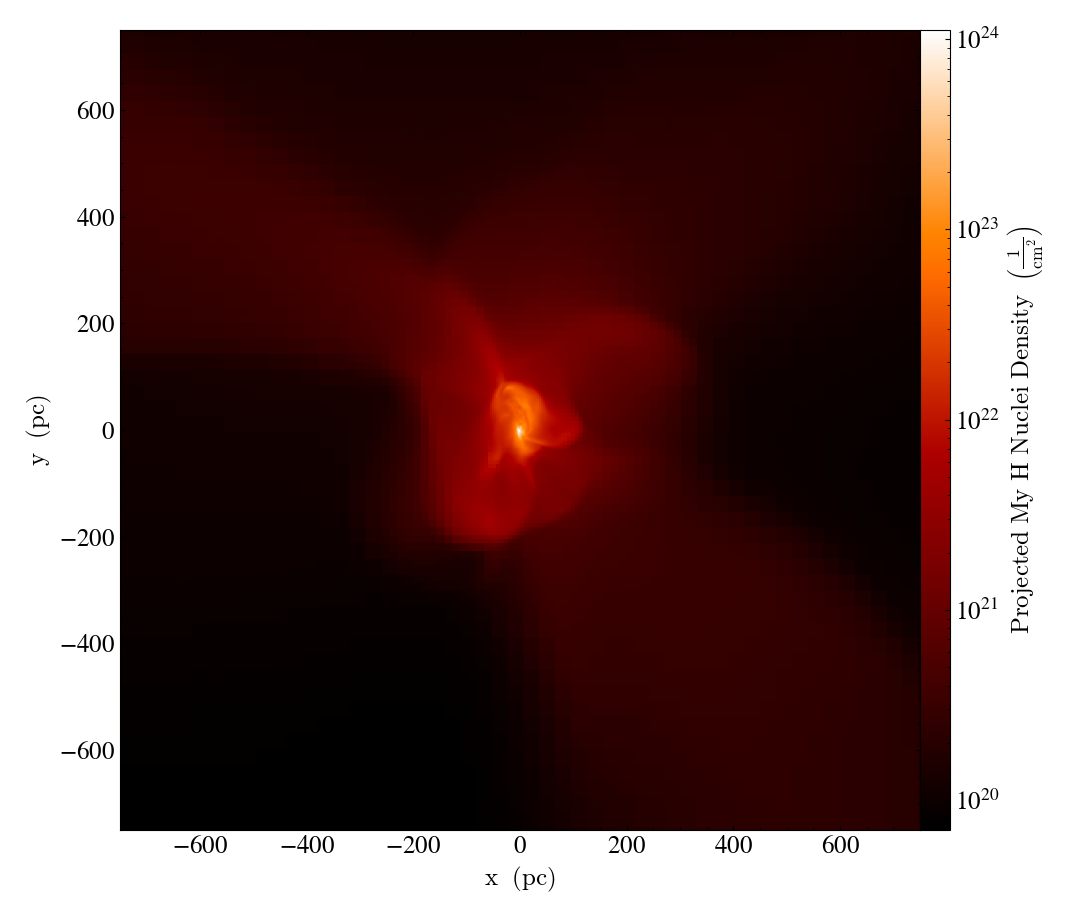

In [21]:
proj5 = yt.ProjectionPlot(ds, "z", ('gas', 'my_H_nuclei_density'), width=width, data_source=sp, center=center_pc)
proj5.set_cmap(('gas', 'my_H_nuclei_density'), "RED TEMPERATURE")
proj5.show()